# Statistical Analysis - AI Networks

This notebook provides a statistical dashboard for the AI enterprise database.

## Objective

Measure database quality (completeness, validation) and describe its structure (country, year, sectors).

## Purposes

- Measure data coverage (completeness and validation).
- Describe the structure of the corpus (country, year, sector).
- Produce reusable exports for data governance.

## Reading Convention

Each section follows the schema: **Objective -> Input -> Processing -> Output**.

## Database Construction Principle

The database follows a semi-manual iterative logic: multi-source seeding, enrichment, deduplication, cross-validation, and then a new iteration.

## Enrichment Loop Schema

1. Multi-source seeding.
2. Snowball enrichment.
3. Deduplication and normalization.
4. Targeted research on blind spots.
5. Human validation and database re-injection.

```mermaid
flowchart LR
    A[Seeding] --> B[Enrichment]
    B --> C[Deduplication]
    C --> D[Targeted Research]
    D --> E[Validation]
    E --> F[Database Update]
    F --> B
```

## 1. Configuration and Data Loading

**Objective**: initialize the environment, load enterprises from `database.db`, and prepare analytical columns.

**Input**: `enterprises` table in the local SQLite database.
**Processing**: robust parsing of `capitalization`, normalization of `is_validated`.
**Output**: DataFrame `df` ready for analysis.

In [16]:
import sqlite3
from pathlib import Path
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

# Configuration des graphiques
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('seaborn-darkgrid')

sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

ROOT = Path(__file__).parent.parent if "__file__" in dir() else Path().resolve().parent
DB_PATH = ROOT / "database.db"

print("✓ Bibliothèques importées")
print(f"✓ Base SQLite: {DB_PATH}")

✓ Bibliothèques importées
✓ Base SQLite: C:\Users\33623\Documents\___Projets\AI\Reseaux d'acteurs\database.db


In [17]:
from pathlib import Path
import sys

ANALYSES_DIR = ROOT / "analyses"
if str(ANALYSES_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSES_DIR))

from country_palette import build_country_colors

In [18]:
# Charger les données depuis la base SQLite locale
def parse_capitalization_millions(value):
    """Convertit la capitalisation format FR (ex: '1 234,56') en float (millions)."""
    if value is None:
        return 0.0
    text = str(value).strip()
    if text == '' or text == '0':
        return 0.0
    text = text.replace(' ', '').replace('\u202f', '').replace('\u00a0', '').replace(',', '.')
    try:
        return float(text)
    except ValueError:
        return 0.0

def normalize_country_name(value):
    if value is None or pd.isna(value):
        return 'Unknown'
    text = str(value).strip()
    if not text or text.casefold() == 'nan':
        return 'Unknown'
    mapping = {
        'south corea': 'South Korea',
        'korea, south': 'South Korea',
        'republic of korea': 'South Korea',
        'danemark': 'Denmark',
        'u.s.': 'United States',
        'usa': 'United States',
        'united states of america': 'United States',
        'uk': 'United Kingdom',
    }
    key = text.casefold()
    return mapping.get(key, text)

SECTOR_ANALYTIC_MAP = {
    'AI': ('AI model',),
    'AI lab': ('AI model',),
    'Artificial Intelligence': ('AI model',),
    'Aerospace & Defence': ('Aerospace', 'Defence'),
    'Brain AI': ('HealthTech',),
    'Computer vision': ('AI model',),
    'Defense': ('Defence',),
    'Health': ('HealthTech',),
    'Health & Social Care': ('HealthTech',),
    'Healthtech': ('HealthTech',),
    'HR': ('HRM',),
    'LawTech': ('LegalTech',),
    'Legal tech': ('LegalTech',),
    'Legal Technology': ('LegalTech',),
    'Med tech': ('MedTech',),
    'Medical Tech': ('MedTech',),
    'Oncology': ('HealthTech',),
    'Public Sector & Aerospace': ('Aerospace', 'Public Sector'),
    'Recruiting': ('HRM',),
    'Speech': ('AI model',),
    'Vision': ('AI model',),
}

SECTOR_PLACEHOLDERS = {'N/A', 'NA', 'N', 'A'}

def normalize_sector_labels(value):
    """Return sorted analytical labels after applying the approved sector rules."""
    if value is None or pd.isna(value):
        return []
    labels = []
    for raw_label in str(value).split(','):
        label = re.sub(r'\s+', ' ', raw_label).strip()
        if not label or label.upper() in SECTOR_PLACEHOLDERS:
            continue
        labels.extend(SECTOR_ANALYTIC_MAP.get(label, (label,)))
    return sorted(set(labels), key=str.casefold)

def build_sector_analysis_frame(frame):
    """Create one analytical row per enterprise and normalized sector label."""
    rows = []
    for _, row in frame.iterrows():
        labels = normalize_sector_labels(row.get('sector')) or ['Unknown']
        for label in labels:
            item = row.copy()
            item['sector_label'] = label
            rows.append(item)
    return pd.DataFrame(rows)

def normalize_sector_label(value):
    labels = normalize_sector_labels(value)
    return ', '.join(labels) if labels else 'Unknown'

def sql_num_expr(column_name):
    cleaned = f"REPLACE(REPLACE(REPLACE(REPLACE(TRIM({column_name}), ' ', ''), CHAR(160), ''), CHAR(8239), ''), ',', '.')"
    return (
        f"CASE "
        f"WHEN NULLIF(TRIM({column_name}), '') IS NULL THEN NULL "
        f"WHEN LOWER(TRIM({column_name})) IN ('na', 'n/a', 'none', 'null', 'unknown') THEN NULL "
        f"WHEN LENGTH({cleaned}) - LENGTH(REPLACE({cleaned}, '.', '')) > 1 "
        f"THEN CAST(REPLACE({cleaned}, '.', '') AS REAL) "
        f"ELSE CAST({cleaned} AS REAL) END"
    )

try:
    if not DB_PATH.exists():
        raise FileNotFoundError(f"Base introuvable: {DB_PATH}")

    cap_sql = sql_num_expr('capitalization')
    funds_sql = sql_num_expr('funds_raised')

    query = f"""
    WITH base AS (
        SELECT
            id,
            name,
            sector,
            country,
            founded_year,
            capitalization,
            is_validated,
            description,
            website,
            headquarter_city,
            main_investors,
            funds_raised,
            created_at,
            updated_at,
            {cap_sql} AS capitalization_millions,
            {funds_sql} AS funds_raised_millions
        FROM enterprises
    )
    SELECT
        *
    FROM base
    WHERE capitalization_millions > 50
       OR ((capitalization_millions = 0 OR capitalization_millions IS NULL)
           AND funds_raised_millions > 10)
    """

    with sqlite3.connect(DB_PATH) as con:
        df = pd.read_sql_query(query, con)

    # Normalise le schema pour eviter les KeyError si des colonnes manquent.
    expected_defaults = {
        'id': None,
        'name': None,
        'sector': None,
        'country': None,
        'founded_year': None,
        'capitalization': '0',
        'is_validated': 0,
        'description': None,
        'website': None,
        'headquarter_city': None,
        'main_investors': None,
        'funds_raised': None,
        'created_at': None,
        'updated_at': None,
    }
    for col, default in expected_defaults.items():
        if col not in df.columns:
            df[col] = default

    df['country'] = df['country'].apply(normalize_country_name)
    df['sector'] = df['sector'].apply(normalize_sector_label)
    df['sector_primary'] = df['sector'].astype(str).str.split(',').str[0].str.strip().replace('', 'Unknown')

    df['capitalization'] = df['capitalization'].fillna('0').astype(str)
    df['capitalization_millions'] = pd.to_numeric(df['capitalization_millions'], errors='coerce').fillna(0.0)
    df['is_validated'] = pd.to_numeric(df['is_validated'], errors='coerce').fillna(0).astype(int)

    non_validees = (df['is_validated'] == 0).sum() if not df.empty else 0
    partiellement_validees = (df['is_validated'] == 1).sum() if not df.empty else 0
    validees = (df['is_validated'] == 2).sum() if not df.empty else 0

    print(f"✓ {len(df)} entreprises chargées depuis la base")
    print(
        f"Validation: non={non_validees}, "
        f"partiel={partiellement_validees}, valide={validees}"
    )
    print(f"\nColonnes: {df.columns.tolist()}")
except Exception as e:
    print(f"✗ Erreur: {e}")
    df = pd.DataFrame()

✓ 325 entreprises chargées depuis la base
Validation: non=4, partiel=71, valide=179

Colonnes: ['id', 'name', 'sector', 'country', 'founded_year', 'capitalization', 'is_validated', 'description', 'website', 'headquarter_city', 'main_investors', 'funds_raised', 'created_at', 'updated_at', 'capitalization_millions', 'funds_raised_millions', 'sector_primary']


In [19]:
# Afficher un aperçu des données
print("📊 Aperçu des données:\n")
preview_cols = [
    'id', 'name', 'sector', 'country', 'founded_year',
    'capitalization', 'capitalization_millions', 'is_validated'
]
preview_cols = [c for c in preview_cols if c in df.columns]
print(df[preview_cols].head(10))
print(f"\nShape: {df.shape}")
print(f"\nTypes de données:\n{df.dtypes}")

📊 Aperçu des données:

   id           name                                             sector  \
0   1       Cerebras                                           Hardware   
1   2      Anthropic                                           Hardware   
2   3     Mistral AI                                           AI model   
3   4         Google  AI model, Marketing, Media & Entertainment, Sales   
4   5      Microsoft    AI model, Cloud Provider, Professional Services   
5   7   Hugging Face                     AI model, Cloud Provider, Data   
6   8          DeepL                                                ICT   
7   9            AWS                                           Hardware   
8  10         GitHub                    AI model, Professional Services   
9  11  Perplexity AI                                                ICT   

         country  founded_year capitalization  capitalization_millions  \
0  United States        2016.0        18000.0                  18000.0   
1  

**Quick Read**: this step validates loading quality (columns, types, volume) before any statistical calculation.

## 2. General Statistics and Completeness

**Objective**: measure the fill rate of each field to prioritize enrichment.

**Output**: completeness table and a visualization of the best- and worst-covered columns.

📈 Taux de Complétude des Champs:

id                       : 325/325 (100.0%)
name                     : 325/325 (100.0%)
sector                   : 325/325 (100.0%)
country                  : 325/325 (100.0%)
founded_year             : 264/325 ( 81.2%)
capitalization           : 266/325 ( 81.8%)
is_validated             : 325/325 (100.0%)
description              : 324/325 ( 99.7%)
website                  : 289/325 ( 88.9%)
headquarter_city         : 238/325 ( 73.2%)
main_investors           : 122/325 ( 37.5%)
funds_raised             : 218/325 ( 67.1%)
created_at               : 325/325 (100.0%)
updated_at               : 325/325 (100.0%)
funds_raised_millions    : 218/325 ( 67.1%)


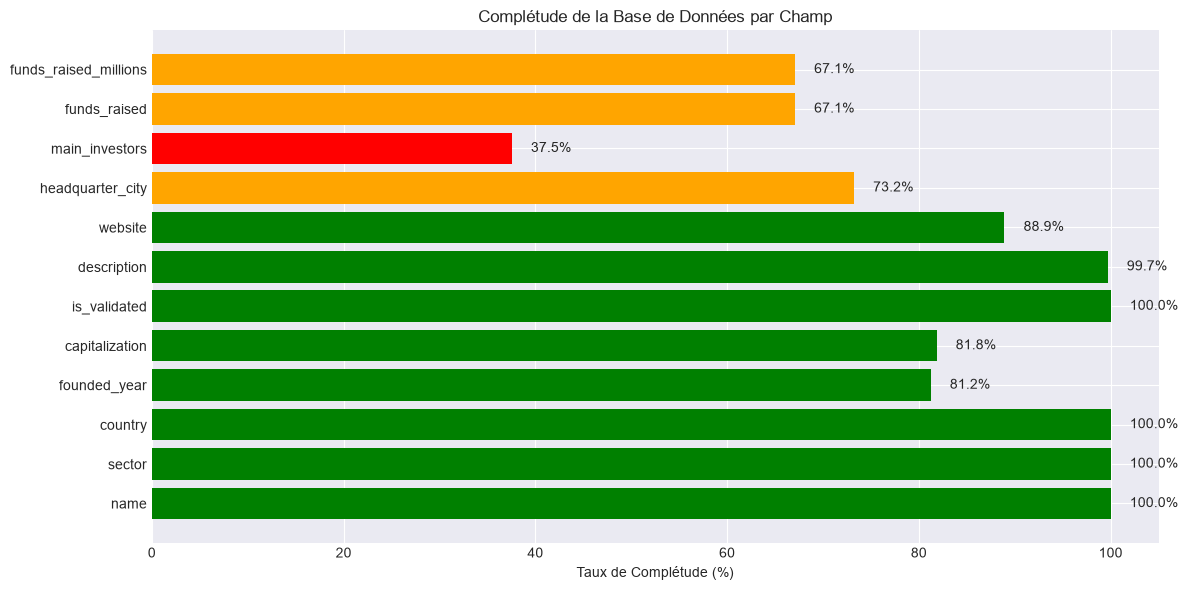

In [20]:
# Statistiques de complétude
print("📈 Taux de Complétude des Champs:\n")

def filled_series(series):
    return series.notna() & (series.astype(str).str.strip() != '')

completeness = {}
for col in df.columns:
    if col in {'capitalization_millions', 'sector_primary'}:
        continue
    if col == 'capitalization':
        # Règle métier: '0' = pas d'information de capitalisation
        non_null = (df['capitalization_millions'] > 0).sum() if 'capitalization_millions' in df.columns else 0
    else:
        non_null = filled_series(df[col]).sum()
    pct = (non_null / len(df)) * 100 if len(df) else 0
    completeness[col] = pct
    print(f"{col:25s}: {non_null:3d}/{len(df)} ({pct:5.1f}%)")

# Visualiser la complétude
fig, ax = plt.subplots(figsize=(12, 6))
cols = [c for c in completeness.keys() if c not in ['id', 'created_at', 'updated_at']]
values = [completeness[c] for c in cols]

bars = ax.barh(cols, values, color=['green' if v >= 80 else 'orange' if v >= 50 else 'red' for v in values])
ax.set_xlabel('Taux de Complétude (%)')
ax.set_title('Complétude de la Base de Données par Champ')
ax.set_xlim(0, 105)

# Ajouter les pourcentages sur les barres
for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(val + 2, i, f'{val:.1f}%', va='center')

plt.tight_layout()
plt.show()

**Quick Read**: fields with low completeness become priority collection targets.

## 3. Distribution by Country

**Objective**: measure the geographic concentration of enterprises in the corpus.

**Outputs**: country ranking, top 10 bar chart, and distribution pie chart.


🌍 Répartition par Pays (28 pays):

country
United States           120
France                   40
Germany                  32
United Kingdom           29
China                    18
Switzerland              13
Unknown                  10
Canada                    8
Israel                    7
India                     6
Poland                    5
Singapore                 5
Netherlands               4
Sweden                    4
Japan                     4
Italy                     3
Brazil                    3
United Arab Emirates      2
Spain                     2
Finland                   2
South Korea               1
Australia                 1
Belgium                   1
Austria                   1
Denmark                   1
Uruguay                   1
Taiwan                    1
Unite                     1
Name: count, dtype: int64


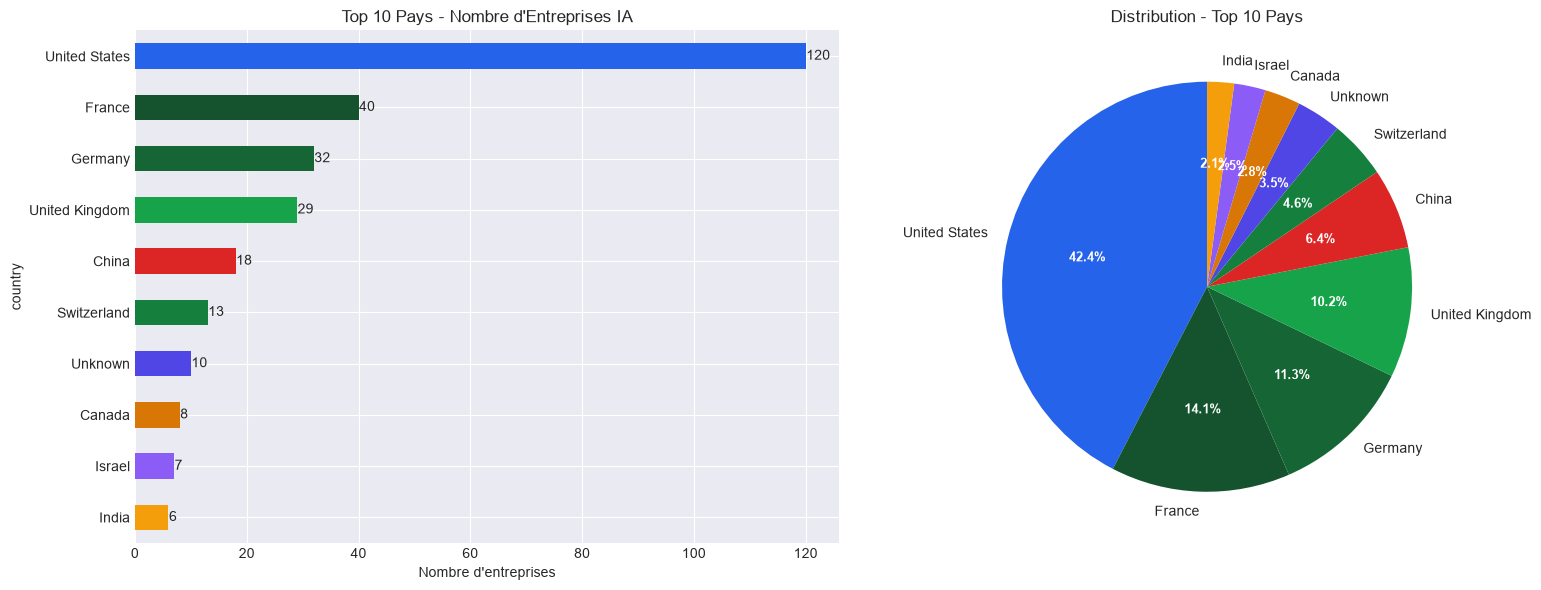

In [21]:
# Repartition par pays
if df is None or df.empty or "country" not in df.columns:
    print("⚠ Aucune donnee pays disponible.")
else:
    country_counts = (
        df["country"]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .replace("", "Unknown")
        .value_counts()
    )

    print(f"\n🌍 Répartition par Pays ({len(country_counts)} pays):\n")
    print(country_counts)

    # Top 10 pays
    top_countries = country_counts.head(10)
    country_colors = build_country_colors(list(top_countries.index))
    top_country_colors = [country_colors[country] for country in top_countries.index]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Graphique 1: Top 10 pays (barre horizontale)
    top_countries.plot(kind='barh', ax=ax1, color=top_country_colors)
    ax1.set_xlabel('Nombre d\'entreprises')
    ax1.set_title('Top 10 Pays - Nombre d\'Entreprises IA')
    ax1.invert_yaxis()

    # Ajouter les chiffres
    for i, v in enumerate(top_countries.values):
        ax1.text(v + 0.1, i, str(v), va='center')

    # Graphique 2: Camembert
    wedges, texts, autotexts = ax2.pie(
        top_countries.values,
        labels=top_countries.index,
        autopct='%1.1f%%',
        colors=top_country_colors,
        startangle=90,
    )
    ax2.set_title('Distribution - Top 10 Pays')

    # Améliorer la lisibilité du texte
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(9)

    plt.tight_layout()
    plt.show()

**Quick Read**: this view highlights the dominant national hubs and the risks of geographic bias.

## 4. Distribution by Year of Foundation

**Objective**: analyze the temporal dynamics of AI enterprise creation.

**Outputs**: period statistics, annual distribution, and trend curve.

In [22]:
# Nettoyer et analyser les annees
year_counts = pd.Series(dtype="int64")
df_year = pd.DataFrame()

if df is None or df.empty or "founded_year" not in df.columns:
    print("⚠ Aucune donnee exploitable pour l'analyse temporelle.")
else:
    year_num = pd.to_numeric(df["founded_year"], errors="coerce")
    df_year = df[year_num.notna()].copy()
    df_year["founded_year"] = year_num[year_num.notna()].astype(int)

    if df_year.empty:
        print("⚠ Aucune annee de fondation renseignee.")
    else:
        year_counts = df_year["founded_year"].value_counts().sort_index()
        print("\n📅 Repartition par Annee de Fondation:\n")
        print(year_counts.tail(20))  # Dernieres 20 annees

        # Statistiques sur les annees
        print(f"\nAnnee la plus ancienne: {df_year['founded_year'].min()}")
        print(f"Annee la plus recente: {df_year['founded_year'].max()}")
        print(f"Mediane: {df_year['founded_year'].median():.0f}")
        print(f"Moyenne: {df_year['founded_year'].mean():.1f}")


📅 Repartition par Annee de Fondation:

founded_year
2006     1
2008     3
2009     4
2010     1
2011     5
2012    11
2013    11
2014     6
2015    11
2016    23
2017    18
2018    15
2019    16
2020    11
2021    16
2022    13
2023    32
2024    16
2025     5
2026     2
Name: count, dtype: int64

Annee la plus ancienne: 1799
Annee la plus recente: 2026
Mediane: 2017
Moyenne: 2012.9


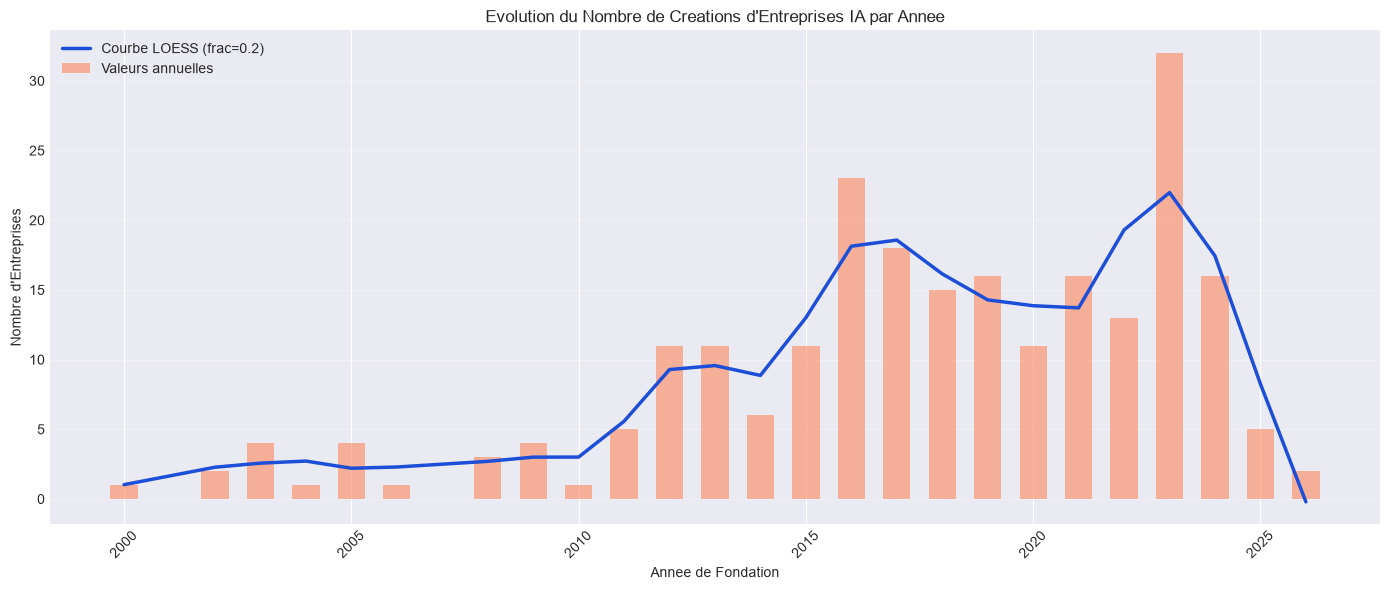

In [23]:
# Visualiser la dynamique annuelle avec courbe LOESS
if "year_counts" not in globals() or year_counts.empty:
    print("⚠ Pas de donnees annuelles a visualiser.")
else:
    fig, ax = plt.subplots(figsize=(14, 6))

    # A partir de 2000
    year_counts_plot = year_counts[year_counts.index >= 2000]

    if year_counts_plot.empty:
        print("⚠ Pas de donnees depuis 2000 pour le graphique annuel.")
    else:
        ax.bar(
            year_counts_plot.index,
            year_counts_plot.values,
            color="coral",
            width=0.6,
            alpha=0.55,
            label="Valeurs annuelles",
        )
        ax.set_xlabel("Annee de Fondation")
        ax.set_ylabel("Nombre d'Entreprises")
        ax.set_title("Evolution du Nombre de Creations d'Entreprises IA par Annee")
        ax.grid(axis="y", alpha=0.3)

        # Courbe LOESS (preset 1: plus fidele aux variations)
        if len(year_counts_plot) >= 3:
            try:
                from statsmodels.nonparametric.smoothers_lowess import lowess

                loess_frac = 0.2
                loess_fit = lowess(
                    endog=year_counts_plot.values,
                    exog=year_counts_plot.index.values,
                    frac=loess_frac,
                    it=0,
                    return_sorted=True,
                )

                ax.plot(
                    loess_fit[:, 0],
                    loess_fit[:, 1],
                    color="#1D4ED8",
                    linewidth=2.5,
                    label=f"Courbe LOESS (frac={loess_frac})",
                )
                ax.legend()
            except ImportError:
                print("⚠ statsmodels non installe: courbe LOESS non tracee.")
            except Exception as e:
                print(f"⚠ Echec du lissage LOESS: {e}")

        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

**Quick Read**: interpretation should be contextualized by the share of records with the year specified.

## 5. Cross-Country × Year Analysis

**Objective**: compare creation rates across the main countries.

**Outputs**: cross-tabulation, heatmap, and stacked area chart for the recent period.

In [24]:
# Creer un tableau croise dynamique
pivot = pd.DataFrame()

required_cols = {"id", "country", "founded_year"}
if df is None or df.empty or not required_cols.issubset(df.columns):
    print("⚠ Donnees insuffisantes pour l'analyse croisee pays x annee.")
else:
    df_analysis = df.copy()
    df_analysis["country"] = df_analysis["country"].fillna("Unknown").astype(str).str.strip()
    df_analysis["country"] = df_analysis["country"].replace("", "Unknown")
    df_analysis["founded_year"] = pd.to_numeric(df_analysis["founded_year"], errors="coerce")
    df_analysis = df_analysis[df_analysis["founded_year"].notna()].copy()
    df_analysis["founded_year"] = df_analysis["founded_year"].astype(int)

    if df_analysis.empty:
        print("⚠ Aucune donnee annee/pays exploitable pour le croise.")
    else:
        # Top 8 pays pour plus de clarte
        top_8_countries = df_analysis["country"].value_counts().head(8).index
        df_top8 = df_analysis[df_analysis["country"].isin(top_8_countries)]

        # Creer un pivot table
        pivot = df_top8.pivot_table(
            values="id",
            index="founded_year",
            columns="country",
            aggfunc="count",
            fill_value=0,
        )

        print("\n📊 Tableau Croise - Top 8 Pays par Annee:\n")
        print(pivot.tail(15))


📊 Tableau Croise - Top 8 Pays par Annee:

country       Canada  China  France  Germany  India  Poland  United Kingdom  \
founded_year                                                                  
2012               0      1       1        0      0       0               3   
2013               0      0       3        0      0       2               0   
2014               0      1       1        1      0       0               0   
2015               0      1       2        2      0       0               2   
2016               1      1       4        1      0       0               4   
2017               1      0       3        2      0       1               2   
2018               0      0       3        1      0       0               1   
2019               1      1       4        2      0       0               2   
2020               0      0       0        3      0       0               3   
2021               0      1       0        2      0       0               2   
2022     

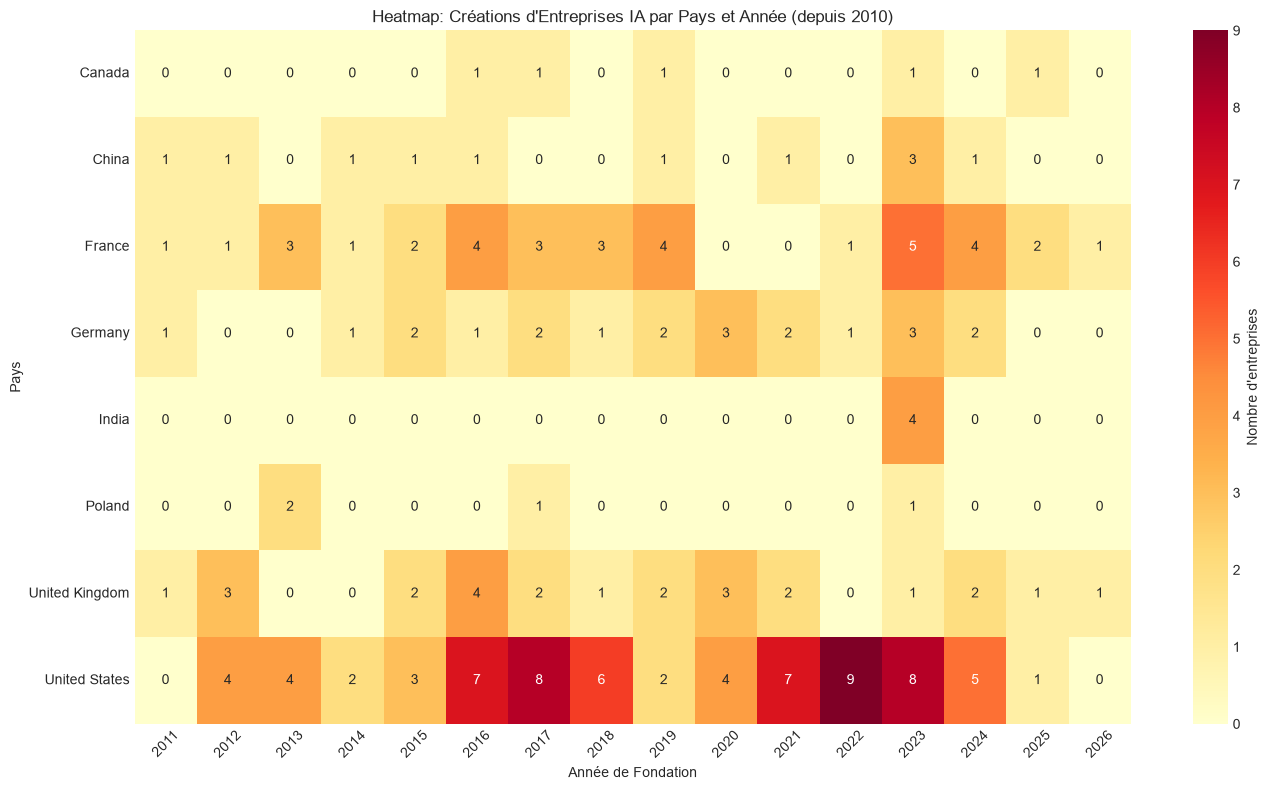

In [25]:
# Visualiser le tableau croisé avec un heatmap
if len(pivot) > 0:
    fig, ax = plt.subplots(figsize=(14, 8))
    
    pivot_recent = pivot[pivot.index >= 2010]  # À partir de 2010
    
    if len(pivot_recent) > 0:
        sns.heatmap(pivot_recent.T, annot=True, fmt='d', cmap='YlOrRd', 
                    cbar_kws={'label': 'Nombre d\'entreprises'}, ax=ax)
        
        ax.set_xlabel('Année de Fondation')
        ax.set_ylabel('Pays')
        ax.set_title('Heatmap: Créations d\'Entreprises IA par Pays et Année (depuis 2010)')
        
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("⚠ Pas de données depuis 2010 pour la heatmap")
else:
    print("⚠ Pas de données croisées disponibles")

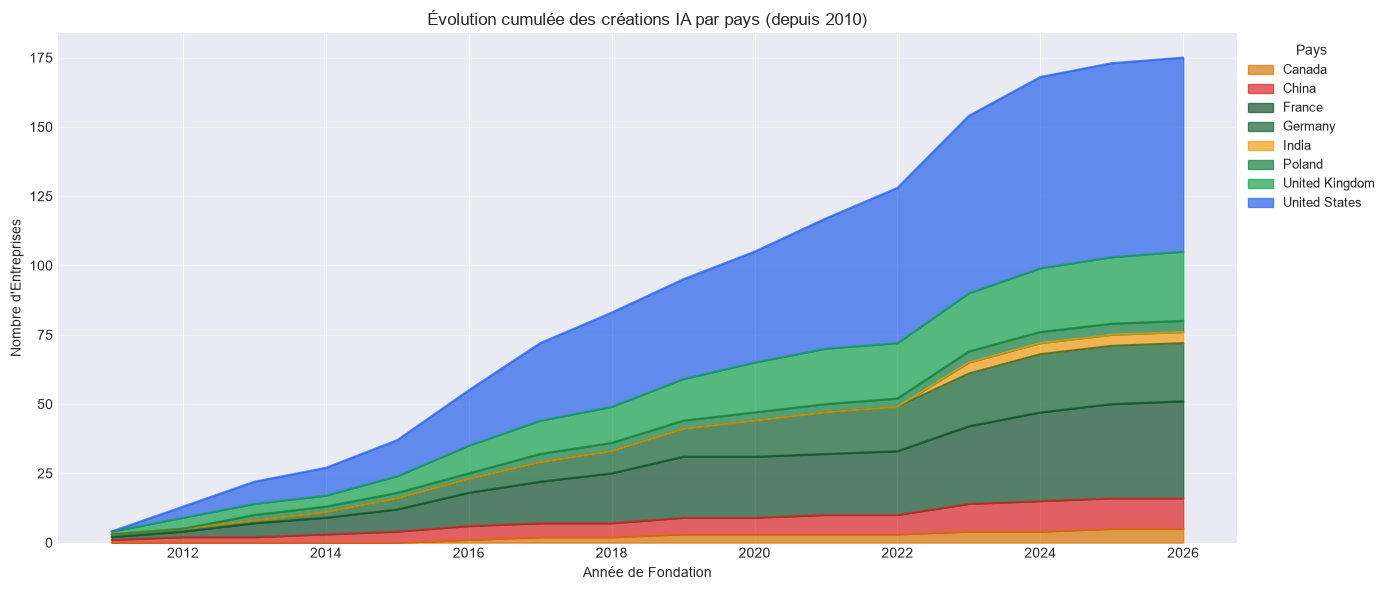

In [26]:
# Graphique en aire empilée
if len(pivot) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))

    pivot_recent = pivot[pivot.index >= 2010]
    
    if len(pivot_recent) > 0:
        country_colors = build_country_colors(list(pivot_recent.columns))
        pivot_cumulative = pivot_recent.cumsum()
        pivot_cumulative.plot.area(
            ax=ax,
            alpha=0.7,
            color=[country_colors.get(country, "#64748B") for country in pivot_cumulative.columns],
        )
        ax.set_xlabel('Année de Fondation')
        ax.set_ylabel('Nombre d\'Entreprises')
        ax.set_title('Évolution cumulée des créations IA par pays (depuis 2010)')
        ax.legend(title='Pays', loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    else:
        print("⚠ Pas de données depuis 2010 pour le graphique")
else:
    print("⚠ Pas de données croisées disponibles")

**Quick Read**: this section distinguishes countries with recent acceleration from those on a stable trajectory.

## 6. Sector Analysis

**Objective**: identify the most represented AI domains using every normalized label assigned to an enterprise.

**Outputs**: full alphabetical sector distribution, top 20 sector chart, and counts that preserve the separation of `Aerospace`, `Defence`, and `Public Sector`.


🔧 Repartition par Secteur (69 labels, ordre alphabetique):

sector_label
AI model                   128
Advertising                  1
Aerospace                    9
Agentic                      5
Automation                   2
                          ... 
Spatial Computing            2
Unknown                      9
Voice & Audio AI             5
Workflow & Productivity      4
neurology                    1
Name: id, Length: 69, dtype: int64


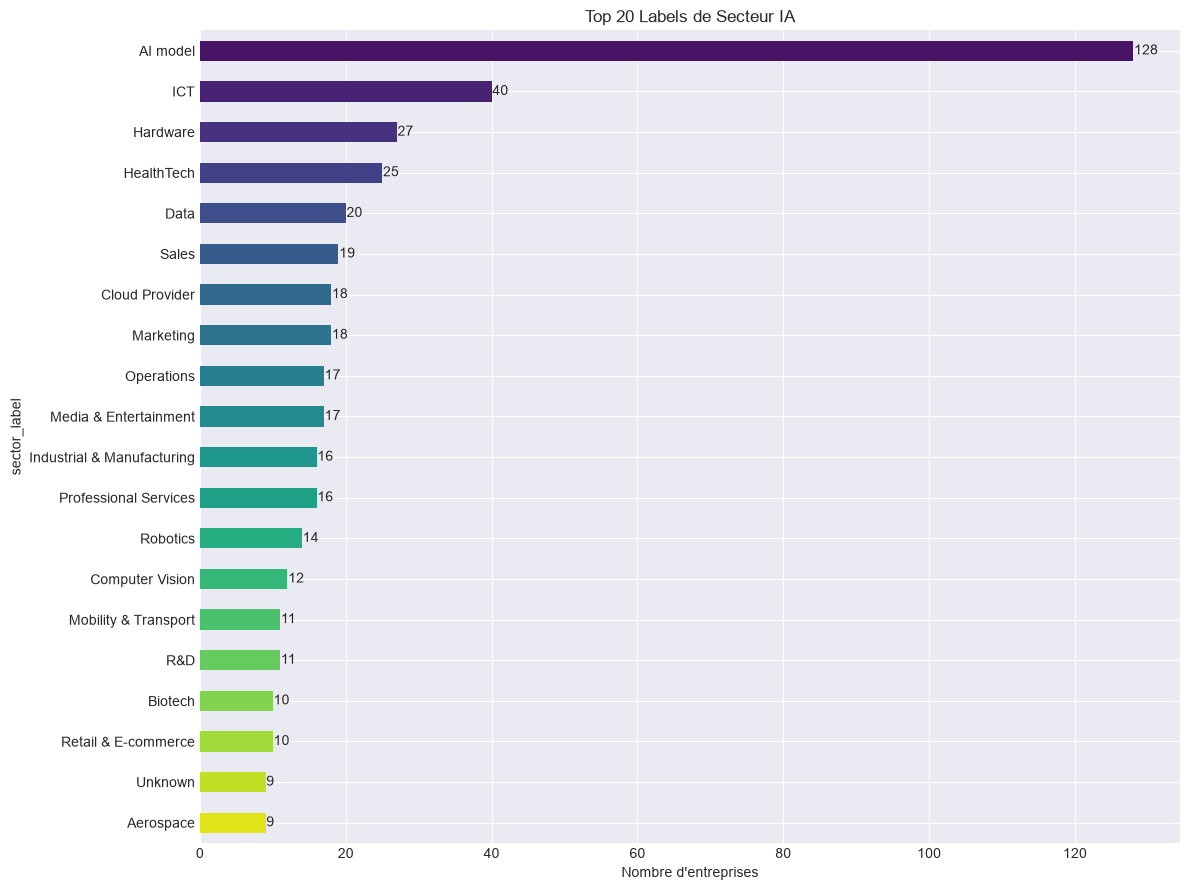

In [27]:
# Secteurs: une ligne analytique par entreprise et label normalise
if df is None or df.empty or "sector" not in df.columns:
    print("⚠ Aucune donnee secteur disponible.")
    sector_analysis = pd.DataFrame()
    sector_counts = pd.Series(dtype="int64")
else:
    sector_analysis = build_sector_analysis_frame(df)
    sector_counts = (
        sector_analysis.groupby("sector_label")["id"]
        .nunique()
        .sort_index()
    )

    print(f"\n🔧 Repartition par Secteur ({len(sector_counts)} labels, ordre alphabetique):\n")
    print(sector_counts)

    # Les fiches multi-labels peuvent apparaitre dans plusieurs secteurs.
    top_sectors = sector_counts.sort_values(ascending=False).head(20)

    if top_sectors.empty:
        print("⚠ Aucun secteur exploitable a visualiser.")
    else:
        fig, ax = plt.subplots(figsize=(12, 9))
        palette = sns.color_palette("viridis", len(top_sectors))
        top_sectors.plot(kind="barh", ax=ax, color=palette)
        ax.set_xlabel("Nombre d'entreprises")
        ax.set_title("Top 20 Labels de Secteur IA")
        ax.invert_yaxis()

        for i, value in enumerate(top_sectors.values):
            ax.text(value + 0.1, i, str(value), va="center")

        plt.tight_layout()
        plt.show()

**Quick Read**: the sector ranking helps prioritize label normalization and targeted enrichment.

## 7. Summary and Insights

**Objective**: consolidate the key KPIs to guide upcoming data initiatives.

**Summary Areas**: volume, geography, temporality, validation, completeness, finance.

In [28]:
# Resume statistique complet (cellule autonome)
if df is None or df.empty:
    print("\n" + "=" * 60)
    print("SYNTHESE - RESEAUX D'ACTEURS IA")
    print("=" * 60)
    print("\n⚠ Aucune donnee disponible.")
    print("=" * 60)
else:
    country_series = (
        df["country"].fillna("Unknown").astype(str).str.strip().replace("", "Unknown")
        if "country" in df.columns else pd.Series(["Unknown"] * len(df))
    )
    sector_analysis_local = build_sector_analysis_frame(df)
    sector_counts_local = (
        sector_analysis_local.groupby("sector_label")["id"]
        .nunique()
        .sort_values(ascending=False)
    )
    country_counts_local = country_series.value_counts()

    df_year_local = pd.DataFrame()
    if "founded_year" in df.columns:
        year_num = pd.to_numeric(df["founded_year"], errors="coerce")
        df_year_local = df[year_num.notna()].copy()
        if not df_year_local.empty:
            df_year_local["founded_year"] = year_num[year_num.notna()].astype(int)

    print("\n" + "=" * 60)
    print("SYNTHESE - RESEAUX D'ACTEURS IA")
    print("=" * 60)

    print("\n📊 GLOBAL")
    print(f"  Total d'entreprises: {len(df)}")
    print(f"  Nombre de pays: {country_counts_local.index.nunique()}")
    print(f"  Nombre de labels de secteur: {sector_counts_local.index.nunique()}")
    if not df_year_local.empty:
        print(f"  Periode couverte: {df_year_local['founded_year'].min():.0f} - {df_year_local['founded_year'].max():.0f}")
    else:
        print("  Periode couverte: non disponible")

    print("\n🌍 TOP PAYS")
    for i, (country, count) in enumerate(country_counts_local.head(5).items(), 1):
        pct = (count / len(df)) * 100
        print(f"  {i}. {country:15s}: {count:3d} entreprises ({pct:5.1f}%)")

    print("\n📅 ANALYSE TEMPORELLE")
    if not df_year_local.empty:
        print(f"  Annee moyenne de creation: {df_year_local['founded_year'].mean():.1f}")
        print(f"  Mediane: {df_year_local['founded_year'].median():.0f}")
        print(f"  Ecart-type: {df_year_local['founded_year'].std():.1f}")
        recent_years = df_year_local[df_year_local["founded_year"] >= 2020]
        pct_recent = (len(recent_years) / len(df_year_local) * 100) if len(df_year_local) else 0
        print(f"  Creations depuis 2020: {len(recent_years)} ({pct_recent:.1f}% du total avec annee)")
    else:
        print("  Donnees temporelles insuffisantes")

    print("\n🔧 TOP LABELS DE SECTEUR")
    for i, (sector, count) in enumerate(sector_counts_local.head(5).items(), 1):
        pct = (count / len(df)) * 100
        print(f"  {i}. {sector:25s}: {count:3d} entreprises ({pct:5.1f}%)")

    print("\n💰 CAPITALISATION (format en millions)")
    if "capitalization_millions" in df.columns:
        cap_vals = pd.to_numeric(df["capitalization_millions"], errors="coerce").fillna(0)
        cap_known = (cap_vals > 0).sum()
        print(f"  Fiches avec capitalisation renseignee (>0): {cap_known} ({(cap_known/len(df)*100):.1f}%)")
        print(f"  Somme des capitalisations (M): {cap_vals.sum():,.1f}".replace(',', ' '))
        print(f"  Mediane (M): {cap_vals.median():,.1f}".replace(',', ' '))
    else:
        print("  Capitalisation indisponible")

    print("\n✅ VALIDATION (3 niveaux)")
    if "is_validated" in df.columns:
        val = pd.to_numeric(df["is_validated"], errors="coerce").fillna(0).astype(int)
        non_validees = (val == 0).sum()
        partiellement_validees = (val == 1).sum()
        validees = (val == 2).sum()
        print(f"  Fiches non validees: {non_validees} ({(non_validees/len(df)*100):.1f}%)")
        print(f"  Fiches validees partiellement: {partiellement_validees} ({(partiellement_validees/len(df)*100):.1f}%)")
        print(f"  Fiches validees: {validees} ({(validees/len(df)*100):.1f}%)")
    else:
        print("  Statut de validation indisponible")

    print("\n📈 COMPLETUDE")
    desc_count = (df["description"].notna() & (df["description"].astype(str).str.strip() != "")).sum() if "description" in df.columns else 0
    web_count = (df["website"].notna() & (df["website"].astype(str).str.strip() != "")).sum() if "website" in df.columns else 0
    cap_info_count = (pd.to_numeric(df["capitalization_millions"], errors="coerce").fillna(0) > 0).sum() if "capitalization_millions" in df.columns else 0
    print(f"  Fiches avec description: {desc_count} ({(desc_count/len(df)*100):.1f}%)")
    print(f"  Fiches avec website: {web_count} ({(web_count/len(df)*100):.1f}%)")
    print(f"  Fiches avec capitalization (>0): {cap_info_count} ({(cap_info_count/len(df)*100):.1f}%)")

    print("\n" + "=" * 60)


SYNTHESE - RESEAUX D'ACTEURS IA

📊 GLOBAL
  Total d'entreprises: 325
  Nombre de pays: 28
  Nombre de labels de secteur: 69
  Periode couverte: 1799 - 2026

🌍 TOP PAYS
  1. United States  : 120 entreprises ( 36.9%)
  2. France         :  40 entreprises ( 12.3%)
  3. Germany        :  32 entreprises (  9.8%)
  4. United Kingdom :  29 entreprises (  8.9%)
  5. China          :  18 entreprises (  5.5%)

📅 ANALYSE TEMPORELLE
  Annee moyenne de creation: 2012.9
  Mediane: 2017
  Ecart-type: 18.6
  Creations depuis 2020: 95 (36.0% du total avec annee)

🔧 TOP LABELS DE SECTEUR
  1. AI model                 : 128 entreprises ( 39.4%)
  2. ICT                      :  40 entreprises ( 12.3%)
  3. Hardware                 :  27 entreprises (  8.3%)
  4. HealthTech               :  25 entreprises (  7.7%)
  5. Data                     :  20 entreprises (  6.2%)

💰 CAPITALISATION (format en millions)
  Fiches avec capitalisation renseignee (>0): 266 (81.8%)
  Somme des capitalisations (M): 38 128 

**Quick Read**: the summary confirms a broad database, but still uneven validation and financial data coverage.

## 8. Results Export

**Objective**: transform the analyses into reusable CSV datasets.

**Expected Files**:
- `statistics_by_country.csv`;
- `statistics_by_sector.csv`;
- `complete_data.csv`.

In [29]:
# Exporter les statistiques cles en CSV
export_dir = "./exports"
os.makedirs(export_dir, exist_ok=True)

try:
    if df is None or df.empty:
        print("⚠ Aucune donnee a exporter.")
    else:
        required_defaults = {
            "id": None,
            "name": None,
            "sector": "Unknown",
            "country": "Unknown",
            "founded_year": np.nan,
            "is_validated": 0,
            "capitalization_millions": 0.0,
            "description": None,
            "website": None,
            "headquarter_city": None,
            "main_investors": None,
            "funds_raised": None,
            "capitalization": None,
        }
        for col, default in required_defaults.items():
            if col not in df.columns:
                df[col] = default

        df["is_validated"] = pd.to_numeric(df["is_validated"], errors="coerce").fillna(0).astype(int)
        df["capitalization_millions"] = pd.to_numeric(df["capitalization_millions"], errors="coerce").fillna(0.0)
        df["country"] = df["country"].fillna("Unknown").astype(str).str.strip().replace("", "Unknown")
        df["sector"] = df["sector"].fillna("Unknown").astype(str).str.strip().replace("", "Unknown")

        # Export 1: Resume par pays
        country_summary = df.groupby("country", dropna=False).agg(
            nombre_entreprises=("id", "count"),
            annee_creation_min=("founded_year", "min"),
            annee_creation_max=("founded_year", "max"),
            annee_creation_moyenne=("founded_year", "mean"),
            capitalisation_millions_totale=("capitalization_millions", "sum"),
            capitalisation_millions_moyenne=("capitalization_millions", "mean"),
            nombre_non_validees=("is_validated", lambda s: (s == 0).sum()),
            nombre_validees_partiellement=("is_validated", lambda s: (s == 1).sum()),
            nombre_validees=("is_validated", lambda s: (s == 2).sum()),
        ).round(1)
        country_summary["taux_validees_partiellement_pct"] = (
            country_summary["nombre_validees_partiellement"] / country_summary["nombre_entreprises"].replace(0, np.nan) * 100
        ).fillna(0).round(1)
        country_summary["taux_validees_pct"] = (
            country_summary["nombre_validees"] / country_summary["nombre_entreprises"].replace(0, np.nan) * 100
        ).fillna(0).round(1)
        country_summary = country_summary.sort_values("nombre_entreprises", ascending=False)
        country_summary.to_csv(f"{export_dir}/statistiques_par_pays.csv")
        print("✓ Exporte: statistiques_par_pays.csv")

        # Export 2: Resume par label de secteur normalise. Les fiches multi-labels
        # sont volontairement presentes une fois par label afin de mesurer chaque domaine.
        sector_analysis_export = build_sector_analysis_frame(df)
        sector_summary = sector_analysis_export.groupby("sector_label", dropna=False).agg(
            nombre_entreprises=("id", "nunique"),
            annee_creation_min=("founded_year", "min"),
            annee_creation_max=("founded_year", "max"),
            annee_creation_moyenne=("founded_year", "mean"),
            capitalisation_millions_totale=("capitalization_millions", "sum"),
            capitalisation_millions_moyenne=("capitalization_millions", "mean"),
            nombre_non_validees=("is_validated", lambda s: (s == 0).sum()),
            nombre_validees_partiellement=("is_validated", lambda s: (s == 1).sum()),
            nombre_validees=("is_validated", lambda s: (s == 2).sum()),
        ).round(1)
        sector_summary["taux_validees_partiellement_pct"] = (
            sector_summary["nombre_validees_partiellement"] / sector_summary["nombre_entreprises"].replace(0, np.nan) * 100
        ).fillna(0).round(1)
        sector_summary["taux_validees_pct"] = (
            sector_summary["nombre_validees"] / sector_summary["nombre_entreprises"].replace(0, np.nan) * 100
        ).fillna(0).round(1)
        sector_summary.index.name = "sector"
        sector_summary = sector_summary.sort_index()
        sector_summary.to_csv(f"{export_dir}/statistiques_par_secteur.csv")
        print("✓ Exporte: statistiques_par_secteur.csv")

        # Export 3: Donnees brutes enrichies
        export_cols = [
            "id", "name", "sector", "country", "founded_year",
            "is_validated", "description", "website",
            "capitalization", "capitalization_millions",
            "headquarter_city", "main_investors", "funds_raised",
        ]
        export_cols = [c for c in export_cols if c in df.columns]
        df_export = df[export_cols].copy()
        df_export.to_csv(f"{export_dir}/donnees_completes.csv", index=False)
        print("✓ Exporte: donnees_completes.csv")

        print(f"\n✓ Tous les exports disponibles dans: {export_dir}/")
except Exception as e:
    print(f"✗ Erreur lors de l'export: {e}")

✓ Exporte: statistiques_par_pays.csv
✓ Exporte: statistiques_par_secteur.csv
✓ Exporte: donnees_completes.csv

✓ Tous les exports disponibles dans: ./exports/


**Quick Read**: these exports are the basis for reporting and longitudinal KPI monitoring.